# Event 04 + Side B — 인플레이션 공식화 × BTC 사상 최고 (2021-11)
## 두 사건을 엮어낸 스토리텔링 차트

### 왜 두 사건을 엮는가
**두 사건은 같은 원인의 쌍둥이 결과**다. 코로나 이후 풀린 유동성이
1. **BTC를 사상 최고 $67,566으로 밀어올렸고** (ⓑ 2021-11-08)
2. **동시에 CPI를 6.2%로 폭발시켰다** (⑤ 2021-11-10 발표, 1990년 이후 최악)

Fed가 9개월간 "transitory(일시적)"로 방어하던 서사가 Powell 의회 증언(11/30)으로 공식 폐기되자, **같은 유동성이 만든 BTC가 -40% 무너지며 크립토 겨울이 시작**됐다. 원인-결과의 고리가 정확히 한 그림에서 보인다.

### 출력
- `data/figures/e04_story/00_prologue.png` … `05_act5.png`
- `data/figures/e04_story/99_summary.png`

## 1. Imports & 경로

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path(os.getcwd()).parent
CPI_PATH   = ROOT / 'data' / 'raw' / 'CPI.csv'
PANEL_PATH = ROOT / 'data' / 'processed' / 'panel_daily.csv'
FIG_DIR    = ROOT / 'data' / 'figures' / 'e04_story'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT    : {ROOT}')
print(f'FIG_DIR : {FIG_DIR}')

ROOT    : c:\Users\kimch\Desktop\project\pandemic-finance
FIG_DIR : c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e04_story


## 2. 데이터 로드 & CPI 릴리스 날짜 매핑

- **BTC**: `panel_daily.csv` 에서 연속 추출
- **CPI YoY**: 원본은 월초 timestamp지만, 시장이 실제 반응한 "발표일"에 맞춰 재인덱싱 (CPI는 전월치를 다음달 10~14일에 발표)

In [2]:
# --- BTC ---
panel = pd.read_csv(PANEL_PATH, index_col=0, parse_dates=True)
btc = panel.loc['2021-09-01':'2022-01-15', 'BTC-USD'].copy()

# --- CPI YoY (월→발표일 매핑) ---
cpi_raw = pd.read_csv(CPI_PATH, index_col=0, parse_dates=True)
cpi_raw['YoY'] = cpi_raw.iloc[:, 0].pct_change(12) * 100

release_map = {
    '2021-08-01': '2021-09-14',
    '2021-09-01': '2021-10-13',
    '2021-10-01': '2021-11-10',
    '2021-11-01': '2021-12-10',
    '2021-12-01': '2022-01-12',
}
cpi_rel = pd.DataFrame([
    {'release_date': pd.Timestamp(v),
     'month_label': pd.Timestamp(k).strftime('%b %Y'),
     'yoy': cpi_raw.loc[k, 'YoY']}
    for k, v in release_map.items()
]).set_index('release_date')

print(f'BTC     : {btc.shape}, {btc.index.min().date()} ~ {btc.index.max().date()}')
print(f'BTC ATH : ${btc.max():,.0f}  on  {btc.idxmax().date()}')
print()
print('CPI YoY (release-date basis):')
print(cpi_rel)

BTC     : (98,), 2021-09-01 ~ 2022-01-14
BTC ATH : $67,567  on  2021-11-08

CPI YoY (release-date basis):
             month_label       yoy
release_date                      
2021-09-14      Aug 2021  5.152015
2021-10-13      Sep 2021  5.351216
2021-11-10      Oct 2021  6.235042
2021-12-10      Nov 2021  6.901970
2022-01-12      Dec 2021  7.174340


## 3. 6국면 정의 — BTC와 CPI가 서로 엮이는 구조

In [3]:
phases = [
    {
        'id': 'prologue', 'name': 'Prologue — 조용한 경고',
        'start': '2021-09-01', 'end': '2021-10-31', 'color': '#90A4AE',
        'narrative': '2021년 가을, 풀린 돈이 BTC를 $40K→$60K로 밀어올렸다. 9월 CPI는 이미 5.4%였지만 Fed는 여전히 "일시적(transitory)"이라 했다.',
        'hero_annotations': [
            ('2021-10-13', 'CPI', 5.4, '9월 CPI 5.4%\nFed: "transitory"', (-80, 25), 'left'),
        ],
    },
    {
        'id': 'act1', 'name': 'Act 1 — BTC 사상 최고 ⓑ',
        'start': '2021-11-01', 'end': '2021-11-08', 'color': '#F7931A',
        'narrative': '11월 8일, BTC가 사상 최고 $67,566을 찍었다. 코로나 이후 풀린 유동성이 만든 역사적 정점 — 그리고 이 돈은 인플레이션의 씨앗이기도 했다.',
        'hero_annotations': [
            ('2021-11-08', 'BTC', 67567, '⭐ BTC 사상 최고\n$67,566', (-25, 25), 'left'),
        ],
    },
    {
        'id': 'act2', 'name': 'Act 2 — CPI 6.2% 충격 ⑤',
        'start': '2021-11-09', 'end': '2021-11-10', 'color': '#E53935',
        'narrative': 'ATH 단 이틀 뒤, 10월 CPI가 6.2%로 발표 — 1990년 이후 최악. 같은 유동성이 한쪽으론 BTC ATH를, 다른쪽으론 인플레이션 폭발을 만들었다는 진실이 숫자로 드러났다.',
        'hero_annotations': [
            ('2021-11-10', 'CPI', 6.2, '⭐ 10월 CPI 6.2%\n(1990 이후 최악)', (-85, 20), 'left'),
            ('2021-11-10', 'BTC', 64995, 'CPI 충격\nBTC -4% (이틀)', (20, -35), 'left'),
        ],
    },
    {
        'id': 'act3', 'name': 'Act 3 — 전이기 균열',
        'start': '2021-11-11', 'end': '2021-11-29', 'color': '#AB47BC',
        'narrative': 'Fed가 "일시적"을 고집하는 사이, 시장은 이미 정반대로 움직였다. BTC는 Black Friday에 $53K까지 추락 — ATH 대비 -21%. 시장이 Fed를 불신하기 시작했다.',
        'hero_annotations': [
            ('2021-11-26', 'BTC', 53570, 'Black Friday\nATH 대비 -21%', (-105, -40), 'left'),
        ],
    },
    {
        'id': 'act4', 'name': 'Act 4 — transitory 폐기 ⑤',
        'start': '2021-11-30', 'end': '2021-11-30', 'color': '#4A148C',
        'narrative': '11월 30일 파월 의회 증언: "\'일시적\'이란 단어를 은퇴시킬 때가 됐다." 9개월 부정이 끝나고 Fed가 공식적으로 긴축 선회를 예고했다.',
        'hero_annotations': [
            ('2021-11-30', 'BTC', 57005, '⭐ Powell 의회 증언\n"transitory 은퇴"\n긴축 선회 공식화', (-160, 20), 'left'),
        ],
    },
    {
        'id': 'act5', 'name': 'Act 5 — 매파 피봇 & 크립토 겨울',
        'start': '2021-12-01', 'end': '2022-01-15', 'color': '#1A237E',
        'narrative': '12월 FOMC: 테이퍼 가속 + 2022년 3차 인상 시사. BTC는 ATH 대비 -36%로 추락하며 크립토 겨울이 시작됐다. CPI는 이후에도 6.9% → 7.0%로 가속.',
        'hero_annotations': [
            ('2021-12-10', 'CPI', 6.9, '11월 CPI 6.9%', (-70, 20), 'left'),
            ('2021-12-15', 'BTC', 48897, 'FOMC 매파 선회\n(2022 3회 인상 시사)', (15, 25), 'left'),
            ('2022-01-12', 'CPI', 7.0, '12월 CPI 7.0%\n(가속 중)', (-30, 15), 'left'),
            ('2022-01-14', 'BTC', 43100, 'ATH -36%\n크립토 겨울', (-110, -30), 'left'),
        ],
    },
]

pd.DataFrame([{k: v for k, v in p.items() if k != 'hero_annotations'} for p in phases])

,id,name,start,end,color,narrative
0,prologue,Prologue — 조용한 경고,2021-09-01,2021-10-31,#90A4AE,"2021년 가을, 풀린 돈이 BTC를 $40K→$60K로 밀어올렸다. 9월 CPI는..."
1,act1,Act 1 — BTC 사상 최고 ⓑ,2021-11-01,2021-11-08,#F7931A,"11월 8일, BTC가 사상 최고 $67,566을 찍었다. 코로나 이후 풀린 유동성..."
2,act2,Act 2 — CPI 6.2% 충격 ⑤,2021-11-09,2021-11-10,#E53935,"ATH 단 이틀 뒤, 10월 CPI가 6.2%로 발표 — 1990년 이후 최악. 같..."
3,act3,Act 3 — 전이기 균열,2021-11-11,2021-11-29,#AB47BC,"Fed가 ""일시적""을 고집하는 사이, 시장은 이미 정반대로 움직였다. BTC는 Bl..."
4,act4,Act 4 — transitory 폐기 ⑤,2021-11-30,2021-11-30,#4A148C,"11월 30일 파월 의회 증언: ""'일시적'이란 단어를 은퇴시킬 때가 됐다."" 9개..."
5,act5,Act 5 — 매파 피봇 & 크립토 겨울,2021-12-01,2022-01-15,#1A237E,12월 FOMC: 테이퍼 가속 + 2022년 3차 인상 시사. BTC는 ATH 대비...


## 4. 공통 상수 & 헬퍼

- **패널 설계**: BTC(연속 라인) + CPI YoY(발표일 바). 바 차트는 월 5개뿐이라 희소하지만 "그 달에 충격이 왔다"는 이벤트성을 살린다.
- **ATH & "transitory 폐기" 두 변곡점을 수직선**으로 교차 표시.

In [4]:
XLIM      = (pd.Timestamp('2021-09-01'), pd.Timestamp('2022-01-15'))
YLIM_BTC  = (38000, 72000)
YLIM_CPI  = (4.5, 7.5)
DIM_COLOR = '#D0D0D0'

BTC_ATH_DATE  = pd.Timestamp('2021-11-08')
POWELL_DATE   = pd.Timestamp('2021-11-30')


def plot_btc_panel(ax, visible_end, phase):
    mask_v = btc.index <= visible_end
    xv, yv = btc.index[mask_v], btc[mask_v]

    ax.plot(xv, yv, color=DIM_COLOR, lw=1.5, alpha=0.85, zorder=2)

    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    mask_a = (xv >= ps) & (xv <= pe)
    if mask_a.any():
        ax.plot(xv[mask_a], yv[mask_a], color=phase['color'], lw=3.2, zorder=5,
                marker='o', markersize=5, markerfacecolor=phase['color'],
                markeredgecolor='white', markeredgewidth=1.2)

    ax.set_ylabel('Bitcoin ($)', fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))


def plot_cpi_panel(ax, visible_end, phase):
    mask_v = cpi_rel.index <= visible_end
    xv = cpi_rel.index[mask_v]
    yv = cpi_rel['yoy'][mask_v]
    labels = cpi_rel['month_label'][mask_v]

    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)

    for xi, yi, lab in zip(xv, yv, labels):
        active = (xi >= ps) and (xi <= pe)
        c = phase['color'] if active else DIM_COLOR
        alpha = 0.95 if active else 0.6
        ax.bar(xi, yi, width=14, color=c, alpha=alpha,
               edgecolor='white', lw=1.0, zorder=3)
        # 월 라벨
        ax.text(xi, yi + 0.08, f'{yi:.1f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color='#111' if active else '#999')
        ax.text(xi, YLIM_CPI[0] + 0.1, lab, ha='center', va='bottom',
                fontsize=7.5, color='#888', rotation=0)

    # 2% 목표 기준선
    ax.axhline(2.0, color='#2E7D32', linestyle='--', lw=1.2, alpha=0.7, zorder=1)
    ax.text(XLIM[0], 2.1, '  Fed 목표 2%', fontsize=9, color='#2E7D32',
            fontweight='bold', va='bottom')

    ax.set_ylabel('CPI 전년 동월 대비 (%)', fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, axis='y', zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def draw_frame(idx, show_future=False):
    phase = phases[idx]
    phase_end = pd.Timestamp(phase['end'])
    visible_end = XLIM[1] if show_future else phase_end + pd.Timedelta(days=2)

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 1.8, 1.2], hspace=0.22)
    ax_rib = fig.add_subplot(gs[0])
    ax_btc = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_cpi = fig.add_subplot(gs[2], sharex=ax_rib)

    # Ribbon
    for i, p in enumerate(phases):
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        active = (i == idx)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.95 if active else 0.18)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center',
                    fontsize=9.5 if active else 8,
                    fontweight='bold' if active else 'normal',
                    color='#111' if active else '#AAA')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    # Title & narrative
    fig.suptitle(f'[{idx+1}/6]  {phase["name"]}',
                 fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.925, phase['narrative'],
             ha='center', va='top', fontsize=11, color='#333',
             style='italic', wrap=True)

    plot_btc_panel(ax_btc, visible_end, phase)
    plot_cpi_panel(ax_cpi, visible_end, phase)
    ax_btc.set_ylim(YLIM_BTC)
    ax_cpi.set_ylim(YLIM_CPI)

    # 두 변곡점 수직선
    if BTC_ATH_DATE <= visible_end:
        alpha = 0.75 if idx >= 1 else 0.2
        for ax in (ax_btc, ax_cpi):
            ax.axvline(BTC_ATH_DATE, color='#F7931A', linestyle=':',
                       lw=1.6, alpha=alpha, zorder=2)
    if POWELL_DATE <= visible_end:
        alpha = 0.75 if idx >= 4 else 0.2
        for ax in (ax_btc, ax_cpi):
            ax.axvline(POWELL_DATE, color='#4A148C', linestyle=':',
                       lw=1.6, alpha=alpha, zorder=2)

    # Hero annotations
    axmap = {'BTC': ax_btc, 'CPI': ax_cpi}
    for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
        ax = axmap[target]
        d = pd.Timestamp(date)
        c = phase['color']
        ax.scatter([d], [y], s=85, color=c, zorder=6,
                   edgecolors='white', lw=1.8)
        ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    ha=ha, color='#111',
                    bbox=dict(boxstyle='round,pad=0.45', fc='white',
                              ec=c, alpha=0.95, lw=1.2),
                    arrowprops=dict(arrowstyle='-', color=c, lw=1.1))

    # X축 (하단만)
    ax_cpi.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax_cpi.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_cpi.tick_params(axis='x', labelsize=9)
    ax_cpi.set_xlabel('2021~2022년', fontsize=10.5)
    for ax in (ax_rib, ax_btc):
        plt.setp(ax.get_xticklabels(), visible=False)

    # Footer
    fig.text(0.5, 0.01,
             'Data: FRED (CPI YoY, 발표일 기준) · Yahoo (BTC-USD)   ·   주황 점선 = BTC ATH (11/08) · 보라 점선 = Powell "transitory 폐기" (11/30)',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.91])

    out = FIG_DIR / f'{idx:02d}_{phase["id"]}.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

## 5. 6프레임 순서대로 생성

C:\Users\kimch\AppData\Local\Temp\ipykernel_23816\2945435122.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.91])


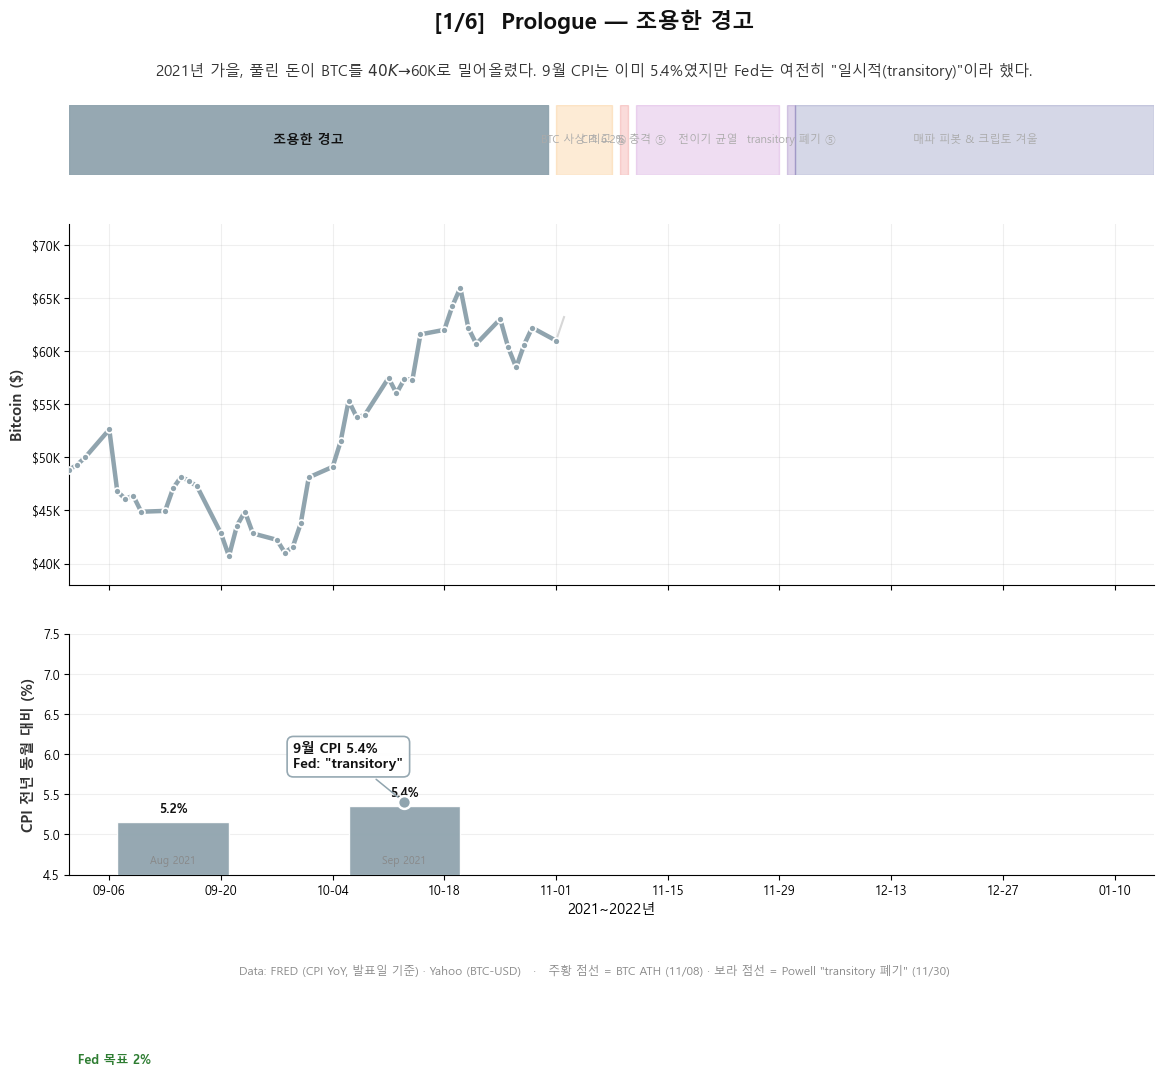

C:\Users\kimch\AppData\Local\Temp\ipykernel_23816\2945435122.py:150: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
c:\Users\kimch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


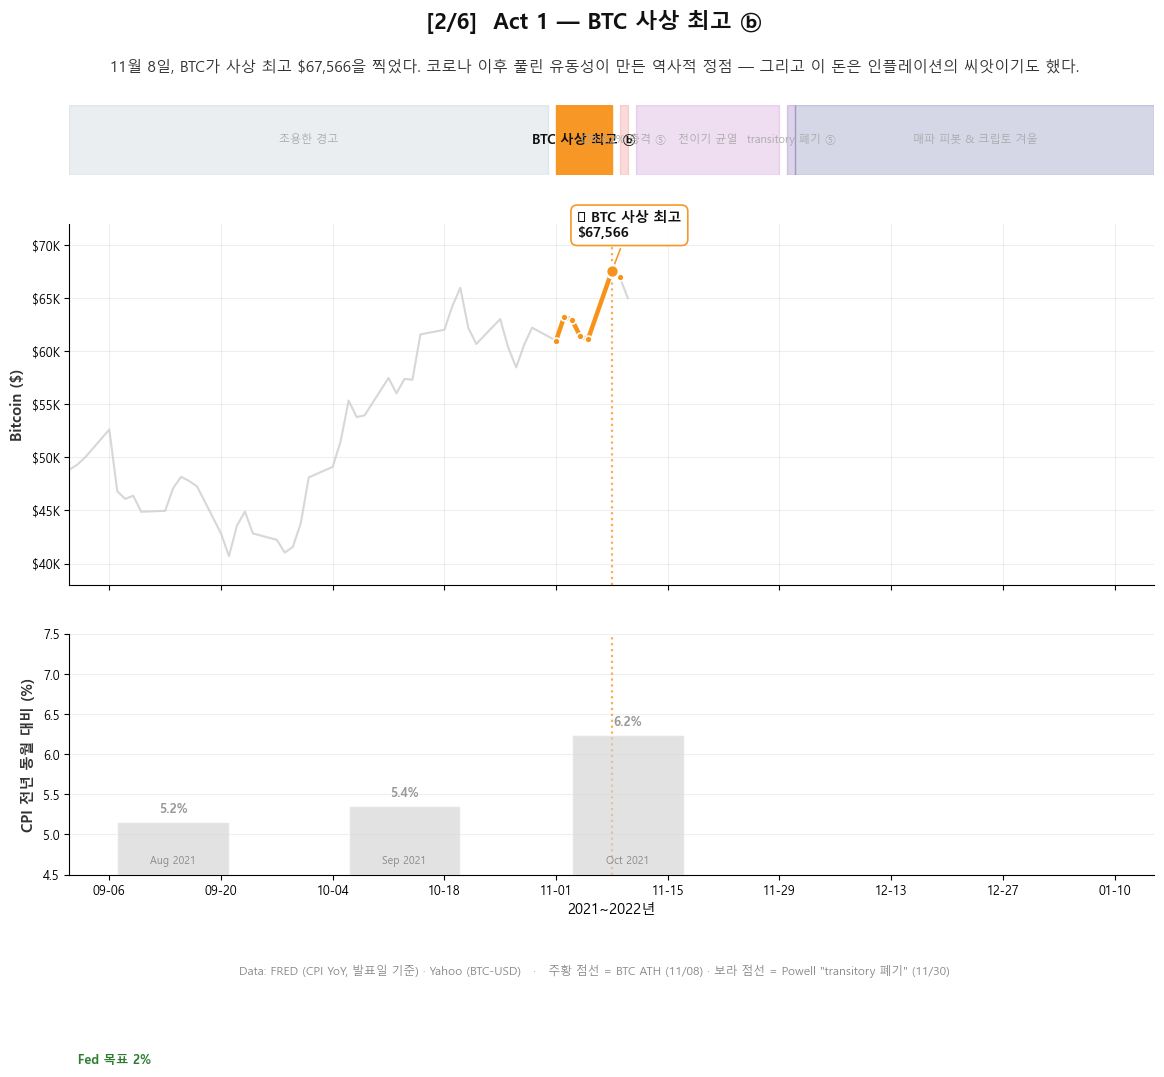

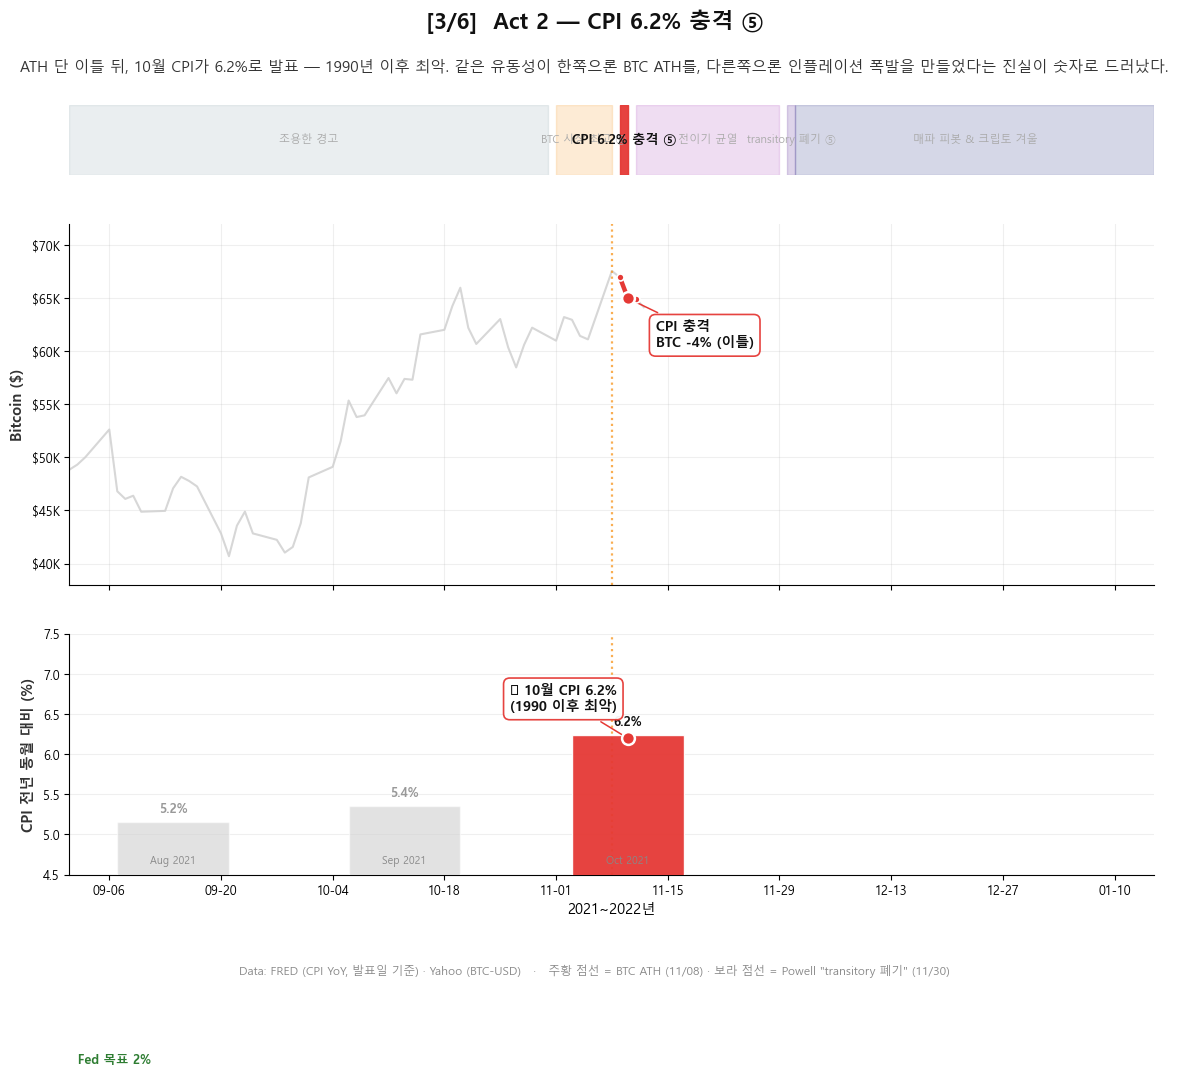

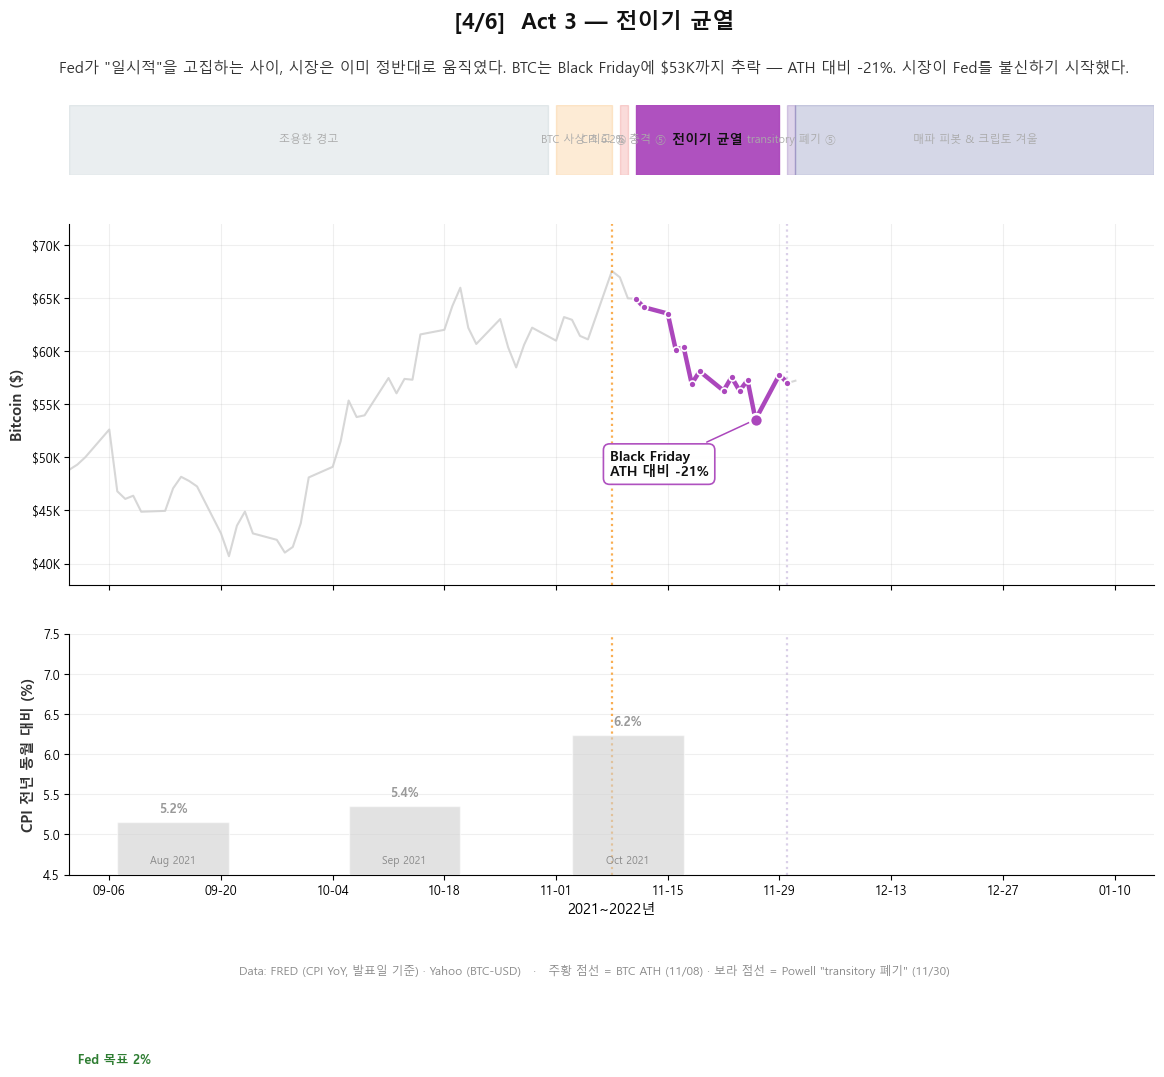

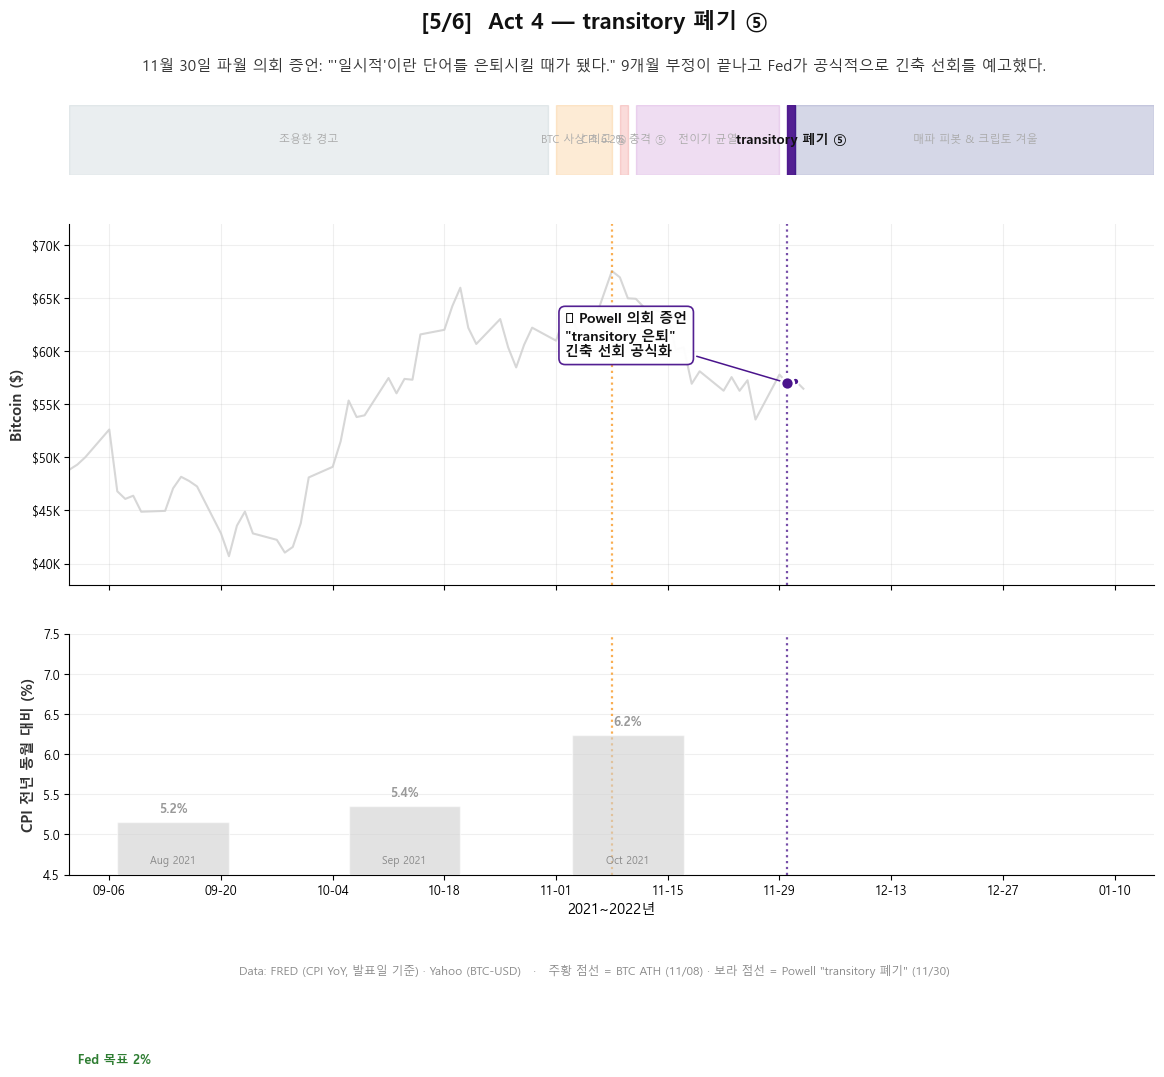

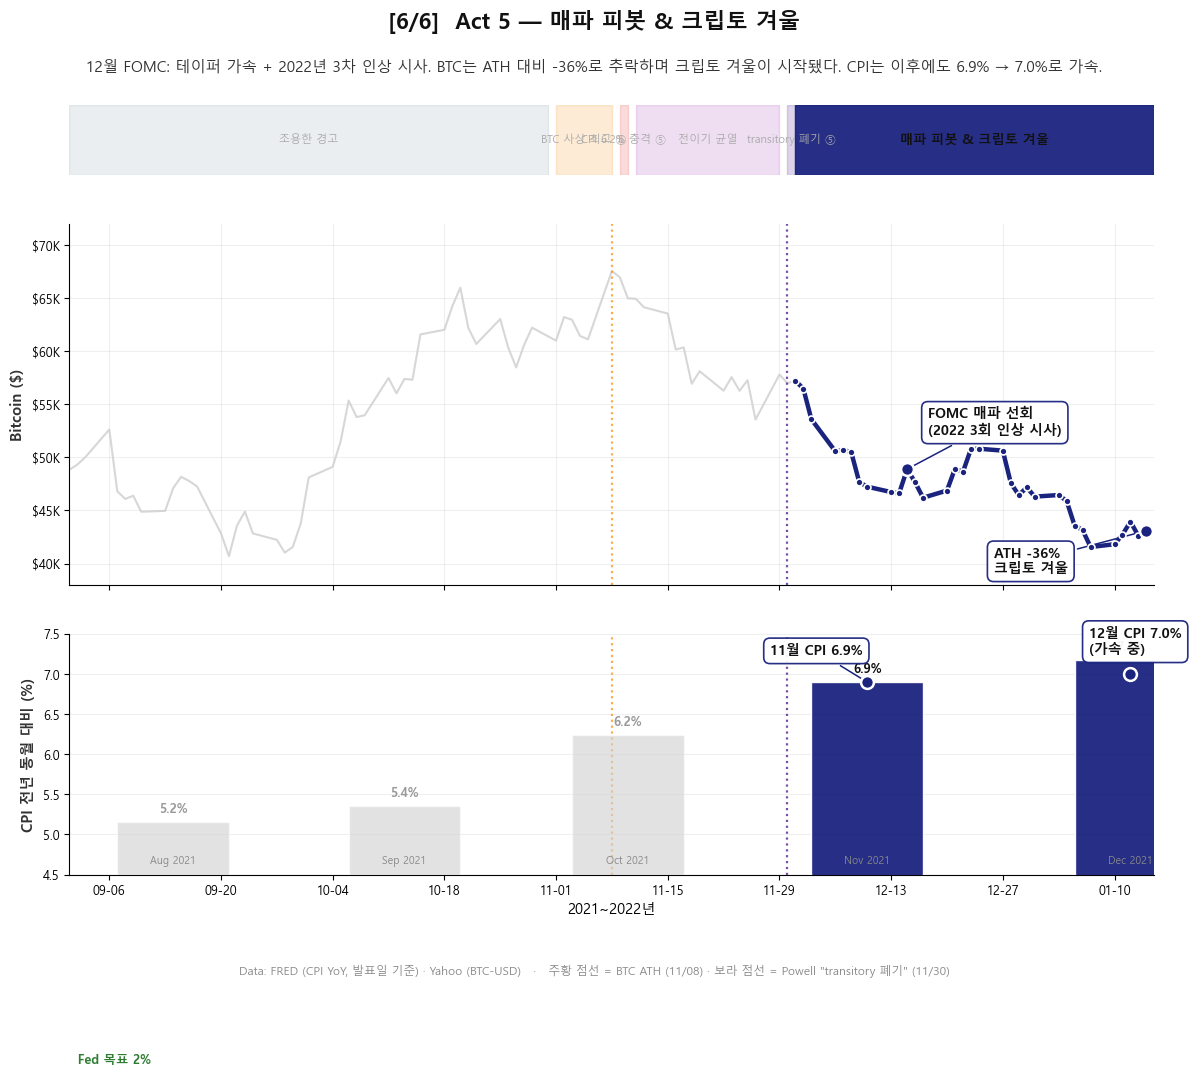


[OK] 저장된 프레임:
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e04_story\00_prologue.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e04_story\01_act1.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e04_story\02_act2.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e04_story\03_act3.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e04_story\04_act4.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e04_story\05_act5.png


In [5]:
saved = []
for i in range(len(phases)):
    fig, path = draw_frame(i)
    saved.append(path)
    plt.show()

print('\n[OK] 저장된 프레임:')
for p in saved:
    print(f'  - {p}')

## 6. 종합 프레임 — 한 장 요약

C:\Users\kimch\AppData\Local\Temp\ipykernel_23816\4292849621.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.91])
C:\Users\kimch\AppData\Local\Temp\ipykernel_23816\4292849621.py:100: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')


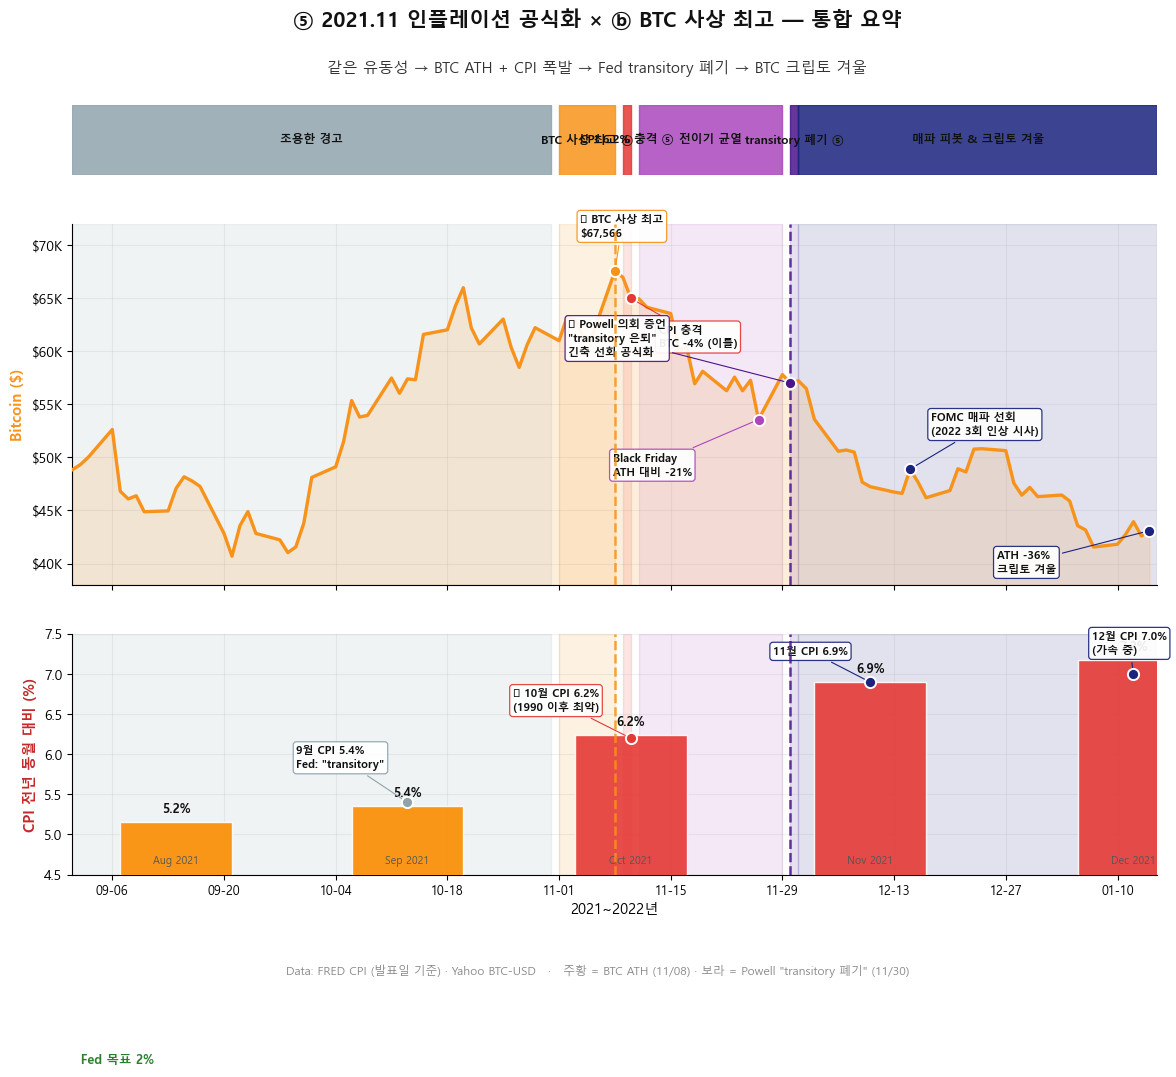


[OK] 종합 프레임: c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e04_story\99_summary.png


In [6]:
def draw_summary():
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 1.8, 1.2], hspace=0.22)
    ax_rib = fig.add_subplot(gs[0])
    ax_btc = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_cpi = fig.add_subplot(gs[2], sharex=ax_rib)

    # Ribbon
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.85)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center', fontsize=8.5,
                    fontweight='bold', color='#111')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle('\u2464 2021.11 인플레이션 공식화 \u00d7 \u24d1 BTC 사상 최고 — 통합 요약',
                 fontsize=15, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.925,
             '같은 유동성 → BTC ATH + CPI 폭발 → Fed transitory 폐기 → BTC 크립토 겨울',
             ha='center', va='top', fontsize=11, color='#333', style='italic')

    # 국면 배경
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        for ax in (ax_btc, ax_cpi):
            ax.axvspan(s, e, color=p['color'], alpha=0.13, zorder=0)

    # BTC
    ax_btc.plot(btc.index, btc, color='#F7931A', lw=2.4, zorder=3)
    ax_btc.fill_between(btc.index, btc, YLIM_BTC[0], color='#F7931A', alpha=0.15, zorder=2)
    ax_btc.set_ylabel('Bitcoin ($)', fontsize=10.5, fontweight='bold', color='#F7931A')
    ax_btc.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

    # CPI
    for xi, yi, lab in zip(cpi_rel.index, cpi_rel['yoy'], cpi_rel['month_label']):
        c = '#E53935' if yi >= 6 else ('#FB8C00' if yi >= 5 else '#90A4AE')
        ax_cpi.bar(xi, yi, width=14, color=c, alpha=0.9,
                   edgecolor='white', lw=1.0, zorder=3)
        ax_cpi.text(xi, yi + 0.08, f'{yi:.1f}%', ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='#111')
        ax_cpi.text(xi, YLIM_CPI[0] + 0.1, lab, ha='center', va='bottom',
                    fontsize=7.5, color='#555')
    ax_cpi.axhline(2.0, color='#2E7D32', linestyle='--', lw=1.2, alpha=0.7, zorder=1)
    ax_cpi.text(XLIM[0], 2.1, '  Fed 목표 2%', fontsize=9,
                color='#2E7D32', fontweight='bold', va='bottom')
    ax_cpi.set_ylabel('CPI 전년 동월 대비 (%)', fontsize=10.5, fontweight='bold', color='#C62828')

    for ax in (ax_btc, ax_cpi):
        ax.grid(alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax_btc.set_ylim(YLIM_BTC)
    ax_cpi.set_ylim(YLIM_CPI)

    # 변곡점 수직선
    for ax in (ax_btc, ax_cpi):
        ax.axvline(BTC_ATH_DATE, color='#F7931A', linestyle='--', lw=1.8, alpha=0.85, zorder=4)
        ax.axvline(POWELL_DATE, color='#4A148C', linestyle='--', lw=1.8, alpha=0.85, zorder=4)

    # 모든 hero annotations
    axmap = {'BTC': ax_btc, 'CPI': ax_cpi}
    for phase in phases:
        for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
            ax = axmap[target]
            d = pd.Timestamp(date)
            c = phase['color']
            ax.scatter([d], [y], s=65, color=c, zorder=6,
                       edgecolors='white', lw=1.4)
            ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                        textcoords='offset points', fontsize=8,
                        fontweight='bold', ha=ha, color='#111',
                        bbox=dict(boxstyle='round,pad=0.28', fc='white',
                                  ec=c, alpha=0.92, lw=0.9),
                        arrowprops=dict(arrowstyle='-', color=c, lw=0.8))

    ax_cpi.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax_cpi.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_cpi.tick_params(axis='x', labelsize=9)
    ax_cpi.set_xlabel('2021~2022년', fontsize=10.5)
    for ax in (ax_rib, ax_btc):
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.text(0.5, 0.01,
             'Data: FRED CPI (발표일 기준) · Yahoo BTC-USD   ·   주황 = BTC ATH (11/08) · 보라 = Powell "transitory 폐기" (11/30)',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.91])

    out = FIG_DIR / '99_summary.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out


fig, path = draw_summary()
plt.show()
print(f'\n[OK] 종합 프레임: {path}')

## 7. 최종 산출물 목록

In [ ]:
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.relative_to(ROOT)}   ({f.stat().st_size // 1024} KB)')